# Mini Project #1

## Spatial Analysis of Crime Patterns in the United Kingdom Using Python and GIS

**Student Name:** Farzeen Mahmood Farooqi
**Course:** GIS Projects and Programming 
**Instructor:** Eric Kerney
**University:** Western Michigan University  
**Date:** 17th March 2026

---

## Project Overview

I love to play around with different datasets and improve my skills with Python and other technical things, I am still learning alot of technical things using python and its libraries. This project studies crime data from the United Kingdom using Python and GIS tools.  
The main goal is to understand crime patterns, compare crime levels across regions, and see where crimes are concentrated on the map.

The project uses official UK Police open data. The data is cleaned, analyzed, and visualized using Python libraries such as Pandas, Matplotlib, and GeoPandas. After that, the dataset is converted into a GeoDataFrame and published to ArcGIS Online using the ArcGIS Python API. Finally, a web map is created manually because of not publish access.

# Problem Statement

Crime does not happen equally in all places. Some regions and locations may have more crime than others, and some types of crime may happen more often in certain areas.

The purpose of this project is to analyze street-level crime data from selected police regions in the United Kingdom. The project focuses on understanding the most common crime types, comparing crime levels between regions, identifying locations with high crime activity, and exploring spatial crime hotspots.

The project also uses crime outcome data to understand what happened after crimes were investigated. This adds more insight to the study.

By combining Python data analysis and GIS mapping, this project shows how crime data can be explored visually and spatially.

# Data Source

The data used in this project comes from the official UK Police open data website:

https://data.police.uk/data/

This website provides public crime and policing data for England and Wales.

For this project, the following datasets were used:

## Street Crime Data
- City of London
- South Yorkshire
- West Yorkshire

## Crime Outcome Data
- City of London
- South Yorkshire
- West Yorkshire

The street crime files include:
- Month
- Longitude
- Latitude
- Location
- Crime type

The outcome files include:
- Crime ID
- Outcome type
- Longitude
- Latitude



# Import Libraries

In [83]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from arcgis.gis import GIS
from arcgis.features import GeoAccessor

# Load the Street Crime Datasets

In [84]:
city = pd.read_csv("2025-12/2025-12-city-of-london-street.csv")
south = pd.read_csv("2025-12/2025-12-south-yorkshire-street.csv")
west = pd.read_csv("2025-12/2025-12-west-yorkshire-street.csv")

# Add Region Names

In [85]:
city["region"] = "City of London"
south["region"] = "South Yorkshire"
west["region"] = "West Yorkshire"

# Create the Main DataFrame

In [86]:
crime_df = pd.concat([city, south, west], ignore_index=True)
crime_df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,region
0,4ba571ce58151d00efdc2a532175c128c43fc40de2e8fb...,2025-12,City of London Police,City of London Police,-0.258524,51.615801,On or near Grenville Place,E01000234,Barnet 021D,Violence and sexual offences,Under investigation,NaN,City of London
1,bfc58b45c83aeb05d5356a9f7d262b30af105e93a6430f...,2025-12,City of London Police,City of London Police,-1.863241,52.413807,On or near Daleview Road,E01008940,Birmingham 115B,Other crime,Under investigation,NaN,City of London
2,5d255922432f2b28d6c5cd4d2588b9b31c99b61af7c519...,2025-12,City of London Police,City of London Police,-0.110350,51.518090,On or near Holborn,E01000917,Camden 027C,Bicycle theft,Investigation complete; no suspect identified,NaN,City of London
3,5cce3898a573bdd78c4f3e8db6bacab541e3f9bf6824db...,2025-12,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Shoplifting,Under investigation,NaN,City of London
4,7a0f6468eff5556be2c41dbc76e79439a5d0bdcb7cab6d...,2025-12,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Violence and sexual offences,Under investigation,NaN,City of London


# Understand the Dataset

In [87]:
crime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36559 entries, 0 to 36558
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crime ID               33325 non-null  object 
 1   Month                  36559 non-null  object 
 2   Reported by            36559 non-null  object 
 3   Falls within           36559 non-null  object 
 4   Longitude              35729 non-null  float64
 5   Latitude               35729 non-null  float64
 6   Location               36559 non-null  object 
 7   LSOA code              35729 non-null  object 
 8   LSOA name              35729 non-null  object 
 9   Crime type             36559 non-null  object 
 10  Last outcome category  33325 non-null  object 
 11  Context                0 non-null      float64
 12  region                 36559 non-null  object 
dtypes: float64(3), object(10)
memory usage: 3.6+ MB


In [88]:
crime_df.shape

(36559, 13)

In [89]:
crime_df.isnull().sum()

Crime ID                  3234
Month                        0
Reported by                  0
Falls within                 0
Longitude                  830
Latitude                   830
Location                     0
LSOA code                  830
LSOA name                  830
Crime type                   0
Last outcome category     3234
Context                  36559
region                       0
dtype: int64

# Data Cleaning

Before analysis, the dataset needs to be cleaned.

The following cleaning steps are carried out:

1. Keep only the important columns
2. Remove rows with missing latitude and longitude
3. Remove duplicate rows

These steps make the dataset easier to work with and improve the quality of the analysis.

# Clean the Data

In [90]:
crime_df = crime_df[[
    "Month",
    "Longitude",
    "Latitude",
    "Location",
    "Crime type",
    "region"
]]

crime_df.columns = [
    "month",
    "longitude",
    "latitude",
    "location",
    "crime_type",
    "region"
]

crime_df = crime_df.dropna(subset=["longitude", "latitude"])
crime_df = crime_df.drop_duplicates()

crime_df.head()

,month,longitude,latitude,location,crime_type,region
0,2025-12,-0.258524,51.615801,On or near Grenville Place,Violence and sexual offences,City of London
1,2025-12,-1.863241,52.413807,On or near Daleview Road,Other crime,City of London
2,2025-12,-0.110350,51.518090,On or near Holborn,Bicycle theft,City of London
3,2025-12,-0.111596,51.518281,On or near Chancery Lane,Shoplifting,City of London
4,2025-12,-0.111596,51.518281,On or near Chancery Lane,Violence and sexual offences,City of London


# Regions 

In [91]:
crime_df["region"].value_counts()

region
West Yorkshire     16001
South Yorkshire     9065
City of London       410
Name: count, dtype: int64

# Create the Outcome DataFrame

In [92]:
city_out = pd.read_csv("2025-12/2025-12-city-of-london-outcomes.csv")
south_out = pd.read_csv("2025-12/2025-12-south-yorkshire-outcomes.csv")
west_out = pd.read_csv("2025-12/2025-12-west-yorkshire-outcomes.csv")

city_out["region"] = "City of London"
south_out["region"] = "South Yorkshire"
west_out["region"] = "West Yorkshire"

outcome_df = pd.concat([city_out, south_out, west_out], ignore_index=True)

outcome_df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Outcome type,region
0,b498c6c5c93120b9e27fafcd7b4e79205f7af84f1e5a5f...,2025-12,City of London Police,City of London Police,NaN,NaN,No location,NaN,NaN,Suspect charged,City of London
1,2a172224985bdb61bb93902cad134e908ba26d170e1238...,2025-12,City of London Police,City of London Police,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect,City of London
2,96838998881aed9cef4153660de28a09f25c27a97078f3...,2025-12,City of London Police,City of London Police,NaN,NaN,No location,NaN,NaN,Investigation complete; no suspect identified,City of London
3,5917f06dd079d3e19bffc23fd579d70d7f68c47dc8d184...,2025-12,City of London Police,City of London Police,NaN,NaN,No location,NaN,NaN,Investigation complete; no suspect identified,City of London
4,6de7abe970f9a04bc0cb2707bd4f0558cde4f696bf4091...,2025-12,City of London Police,City of London Police,NaN,NaN,No location,NaN,NaN,Investigation complete; no suspect identified,City of London


# Clean Outcome Data

In [93]:
outcome_df = outcome_df[[
    "Crime ID",
    "Month",
    "Longitude",
    "Latitude",
    "Outcome type",
    "region"
]]

outcome_df.columns = [
    "crime_id",
    "month",
    "longitude",
    "latitude",
    "outcome_type",
    "region"
]

outcome_df = outcome_df.dropna(subset=["longitude", "latitude"])
outcome_df = outcome_df.drop_duplicates()

outcome_df.head()

,crime_id,month,longitude,latitude,outcome_type,region
6,42c24260a70b4f0c18899d0a48fbc2f181200aeb05485b...,2025-12,-0.109842,51.522012,Local resolution,City of London
7,85100b54ecc33c262386d8a60c470a1a985f42012547a4...,2025-12,-0.086019,51.513631,Investigation complete; no suspect identified,City of London
12,1c79dddadc4ba8bfc3b93084e377091df1392164fd8bfc...,2025-12,-0.101906,51.511794,Unable to prosecute suspect,City of London
13,1764ce1a3eeee25f113f18655bf9558eb91e12bc634b0a...,2025-12,-0.096367,51.515355,Unable to prosecute suspect,City of London
16,2e3e7d2d23412c0fade76301c13570848d167e4d3c6e9c...,2025-12,-0.106076,51.517239,Investigation complete; no suspect identified,City of London


# Research Questions

This project answers the following 13 research questions:

1. What are the most common crime types in the dataset?
2. How many crime incidents are recorded in each region?
3. What percentage of all crimes belongs to each region?
4. Which locations have the highest number of crime incidents?
5. What proportion of crime types occurs in each region?
6. Are there outliers in crime counts across regions?
7. Which Crime types are most common in each region?
8. How are crime incidents distributed geographically?
9. Are there spatial hotspots where crime is concentrated?
10. Is there a relationship between the number of crimes at a location and the variety of crime types recorded there?
11. What are the most common investigation outcomes?
12. How do investigation outcomes differ across regions?
13. How does mapping the data help us understand crime patterns better?

# Research Question 1

## What are the most common crime types in the dataset?

This question helps identify which crime categories appear most often in the combined dataset.

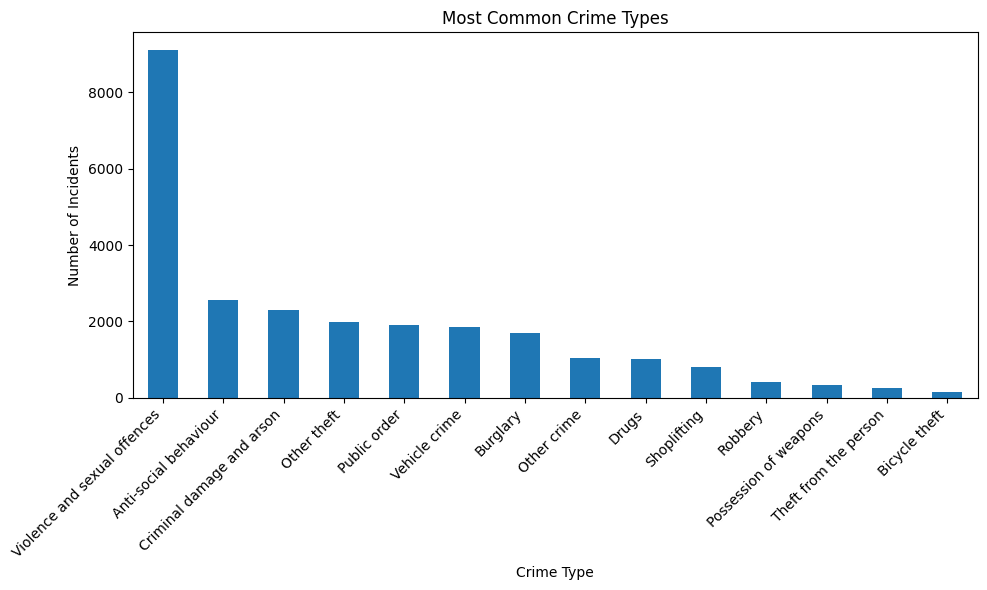

In [94]:
crime_counts = crime_df["crime_type"].value_counts()

plt.figure(figsize=(10, 6))
crime_counts.plot(kind="bar")
plt.title("Most Common Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Summary of Most Common Crime Types

The chart shows the most common crime types in the dataset. The highest number of incidents is for **violence and sexual offences**, which is much greater than all other categories. After that, **anti-social behaviour**, **criminal damage and arson**, and **other theft** are also quite common. Crimes such as **public order**, **vehicle crime**, and **burglary** occur at a moderate level. On the other hand, **drugs**, **shoplifting**, and **robbery** are less frequent. The least common crimes in the dataset are **possession of weapons**, **theft from the person**, and **bicycle theft**.

This analysis was done to identify which crime types occur most frequently in the dataset and to understand overall crime patterns.

This analysis is beneficial because it helps authorities and decision-makers focus on the most common types of crime. By knowing which crimes happen the most, resources can be allocated more effectively, and prevention strategies can be designed to reduce high-frequency offences and improve public safety.

# Research Question 2

## How many crime incidents are recorded in each region?

This question compares the total number of crimes in City of London, South Yorkshire, and West Yorkshire.

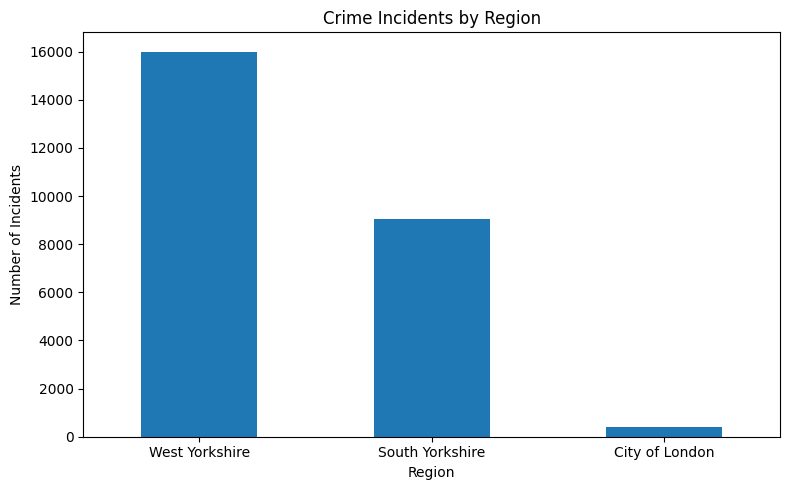

In [95]:
region_counts = crime_df["region"].value_counts()

plt.figure(figsize=(8, 5))
region_counts.plot(kind="bar")
plt.title("Crime Incidents by Region")
plt.xlabel("Region")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Summary of Crime Incidents by Region

The chart shows the total number of crime incidents recorded in each region. **West Yorkshire** has the highest number of crimes, with a significantly larger count compared to the other regions. **South Yorkshire** has the second highest number of incidents, but it is much lower than West Yorkshire. In contrast, the **City of London** has a very small number of recorded crimes, making it the lowest among the three regions. Overall, the data indicates that crime is much more frequent in West Yorkshire, while the City of London experiences very few incidents in comparison.

This analysis was done to compare the total number of crime incidents across different regions and understand regional differences in crime levels.

This analysis is beneficial because it helps authorities identify which regions experience higher crime rates and require more attention. It supports better allocation of resources, improved policing strategies, and more effective planning to reduce crime in high-risk areas.

# Research Question 3

## What percentage of all crimes belongs to each region?

This question shows the share of total crime incidents in each region.

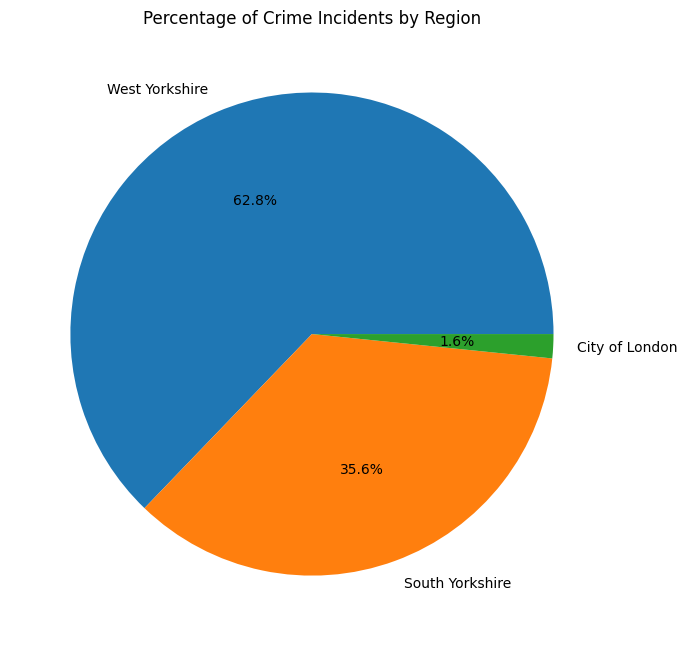

In [96]:
plt.figure(figsize=(7, 7))
crime_df["region"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage of Crime Incidents by Region")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Summary of Crime Percentage by Region

The pie chart shows the percentage of total crime incidents in each region. **West Yorkshire** accounts for the largest share, making up approximately **62.8%** of all crimes. **South Yorkshire** contributes around **35.6%**, which is a significant portion but still much lower than West Yorkshire. In contrast, the **City of London** represents only about **1.6%** of the total crimes, making it the smallest share by a large margin. Overall, the majority of crimes are concentrated in West Yorkshire, while the City of London has a very minimal contribution.

This analysis was done to understand how crime is distributed across different regions and to compare their relative shares. Instead of just looking at total numbers, percentages help give a clearer picture of which areas are most affected.

This analysis is beneficial because it helps policymakers, law enforcement, and local authorities identify high-crime regions and allocate resources more effectively. It also supports better decision-making for crime prevention strategies, allowing efforts to be focused where they are needed the most.

# Research Question 4

## Which locations have the highest number of crime incidents?

This question identifies the places with the largest number of recorded crimes.

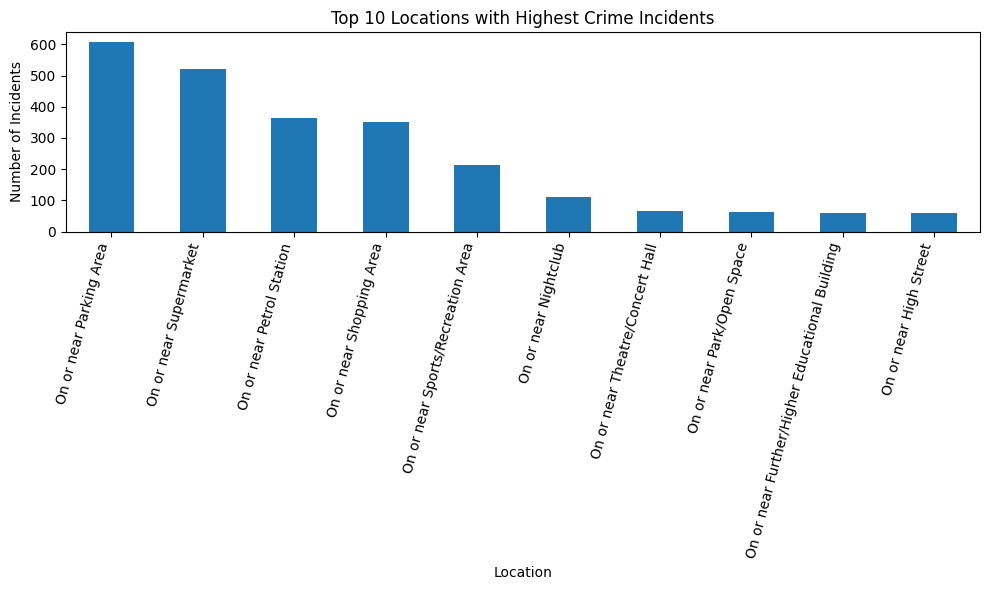

In [97]:
top_locations = crime_df["location"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_locations.plot(kind="bar")
plt.title("Top 10 Locations with Highest Crime Incidents")
plt.xlabel("Location")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### Summary of Locations with Highest Crime Incidents

The bar chart shows the top 10 locations with the highest number of crime incidents. The most common location is **"On or near Parking Area"**, which has the highest number of reported crimes. This is followed by **"On or near Supermarket"**, and then **"On or near Petrol Station"** and **"On or near Shopping Area"**, which also show high levels of crime. Other locations such as **sports/recreation areas**, **nightclubs**, and **theatres/concert halls** have moderate numbers of incidents. The least frequent among the top 10 include places like **parks/open spaces**, **educational buildings**, and **high streets**.

This analysis was done to identify specific locations where crimes occur most frequently. By understanding where crimes are concentrated, it becomes easier to detect patterns related to environment and human activity.

This analysis is beneficial because it helps law enforcement and local authorities focus on high-risk areas and improve safety measures such as increased patrols, better lighting, or CCTV installation. It also helps businesses and the public become more aware of risky locations, leading to better prevention and safety planning.

# Research Question 5

## What proportion of crime types occurs in each region?

This analysis examines the percentage distribution of different crime types within each region. 
By comparing proportions instead of raw counts, we can better understand the relative crime patterns in each region.

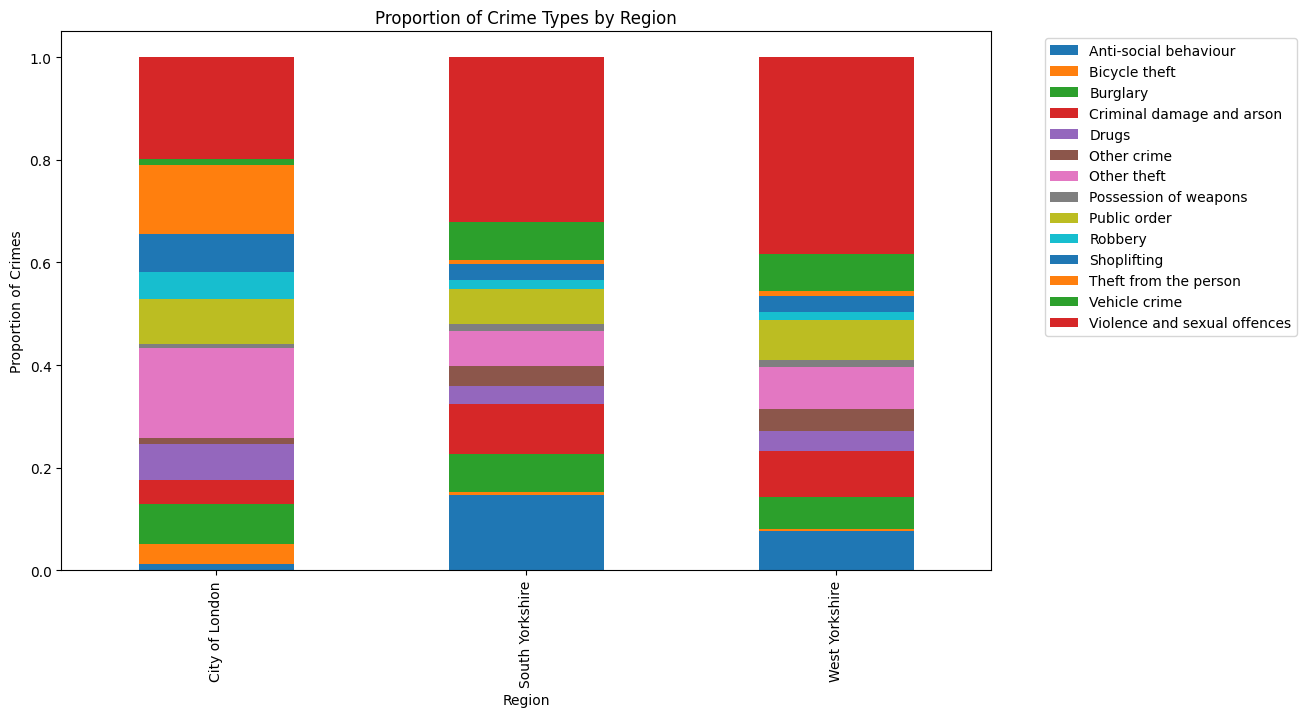

In [98]:
crime_region_prop = pd.crosstab(crime_df["region"], crime_df["crime_type"], normalize="index")

crime_region_prop.plot(kind="bar", stacked=True, figsize=(12,7))

plt.title("Proportion of Crime Types by Region")
plt.xlabel("Region")
plt.ylabel("Proportion of Crimes")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Summary of Proportion of Crime Types by Region

The stacked bar chart shows the proportion of different crime types within each region. Across all regions, **violence and sexual offences** make up the largest share of crimes. In **West Yorkshire** and **South Yorkshire**, this category dominates, along with noticeable contributions from **anti-social behaviour**, **other theft**, and **criminal damage and arson**. In the **City of London**, although the total number of crimes is lower, the distribution is slightly different, with relatively higher proportions of **theft-related crimes** such as other theft and bicycle theft. Other crime types like **drugs**, **robbery**, and **possession of weapons** make up smaller proportions across all regions.

This analysis was done to compare the structure of crime types in each region rather than just total counts. By using proportions, it becomes easier to understand which types of crimes are more common within each region.

This analysis is beneficial because it helps authorities design region-specific crime prevention strategies. For example, areas with higher theft proportions may need better security measures, while areas with more violent crimes may require stronger policing and community interventions. It allows for more targeted and effective decision-making based on the unique crime patterns of each region.

# Research Question 6

## Are there outliers in crime counts across regions?

This question checks whether some locations have unusually high crime counts compared to others in the same region.

<Figure size 1000x600 with 0 Axes>

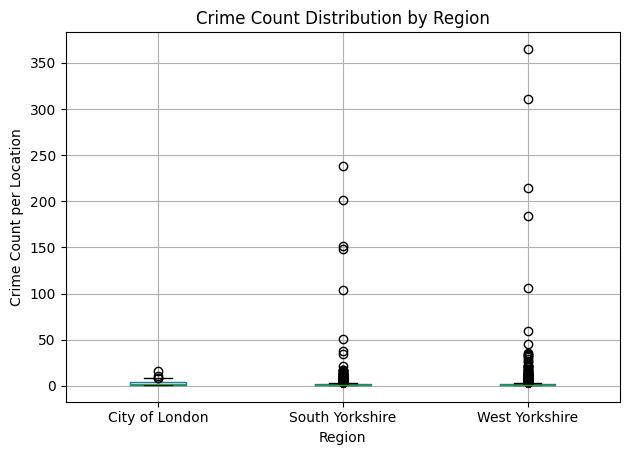

In [99]:
region_location_counts = crime_df.groupby(["region", "location"]).size().reset_index(name="crime_count")

plt.figure(figsize=(10, 6))
region_location_counts.boxplot(by="region", column="crime_count")
plt.title("Crime Count Distribution by Region")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Crime Count per Location")
plt.tight_layout()
plt.show()

### Summary of Outliers in Crime Counts Across Regions

The box plot shows the distribution of crime counts per location across different regions and helps identify outliers. In all regions, most locations have relatively low crime counts, as shown by the concentration of values near the bottom of the plot. However, there are several outliers, especially in **West Yorkshire** and **South Yorkshire**, where some locations have significantly higher crime counts compared to others. These extreme values indicate that certain areas experience unusually high levels of crime. In contrast, the **City of London** has fewer and less extreme outliers, suggesting a more consistent and lower distribution of crime counts across locations.

This analysis was done to detect unusual patterns and identify locations with exceptionally high crime rates within each region. Box plots are useful for highlighting variability and spotting extreme values that may not be obvious in other charts.

This analysis is beneficial because it helps authorities focus on specific high-risk locations that require immediate attention. Identifying outliers allows for targeted interventions, better resource allocation, and more effective crime prevention strategies in areas that deviate significantly from the norm.

# Research Question 7

## Which crime types are most common in each region?

This question compares crime types across the three regions: City of London, South Yorkshire, and West Yorkshire.

Understanding how crime categories differ by region can help identify patterns in criminal activity.

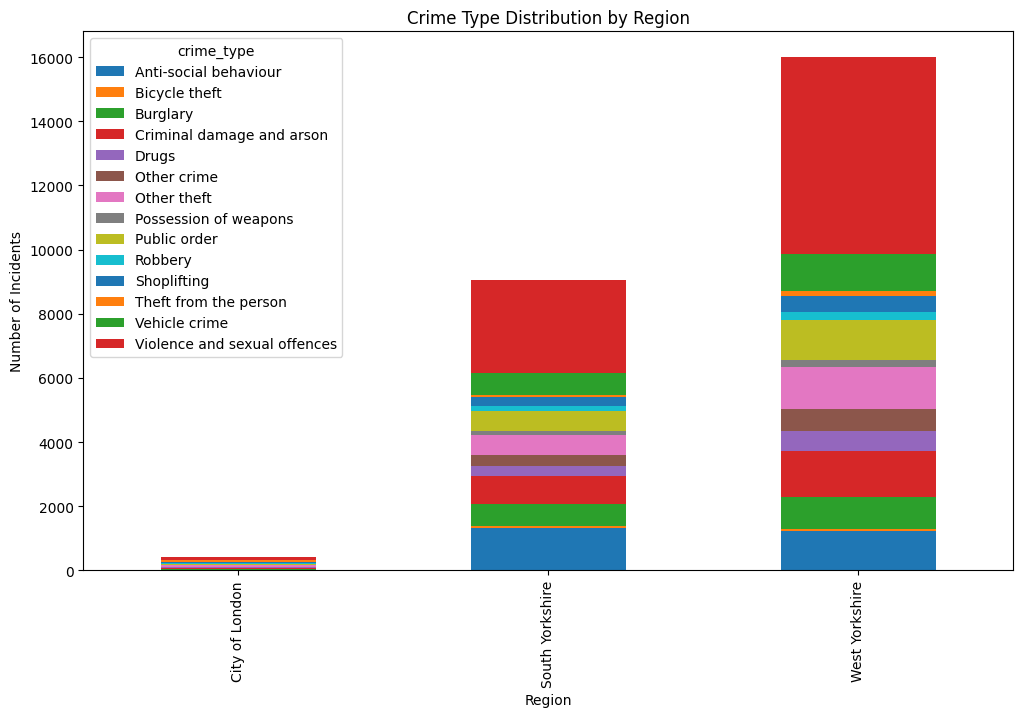

In [100]:
crime_region_table = pd.crosstab(crime_df["region"], crime_df["crime_type"])

crime_region_table.plot(kind="bar", stacked=True, figsize=(12,7))

plt.title("Crime Type Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Incidents")

plt.show()

### Summary of Most Common Crime Types in Each Region

The stacked bar chart shows the distribution of different crime types across each region. In all three regions, **violence and sexual offences** are the most common crime type, contributing the largest portion of incidents. In **West Yorkshire**, this category is especially dominant, followed by **anti-social behaviour**, **criminal damage and arson**, and **other theft**. A similar pattern is observed in **South Yorkshire**, although the total number of crimes is lower. In the **City of London**, the overall number of incidents is much smaller, but **theft-related crimes** such as other theft and bicycle theft make up a noticeable share compared to other categories.

This analysis was done to compare how crime types vary across regions and to identify the most common types within each area. It helps highlight whether certain crimes are more prevalent in specific regions.

This analysis is beneficial because it allows law enforcement and policymakers to develop targeted strategies for each region. For example, areas with higher violent crime may need stronger policing and community support, while regions with more theft-related crimes may benefit from improved security measures. This leads to more effective and region-specific crime prevention efforts.

# Research Question 8

## How are crime incidents distributed geographically?

This question explores the spatial spread of crime incidents using latitude and longitude.

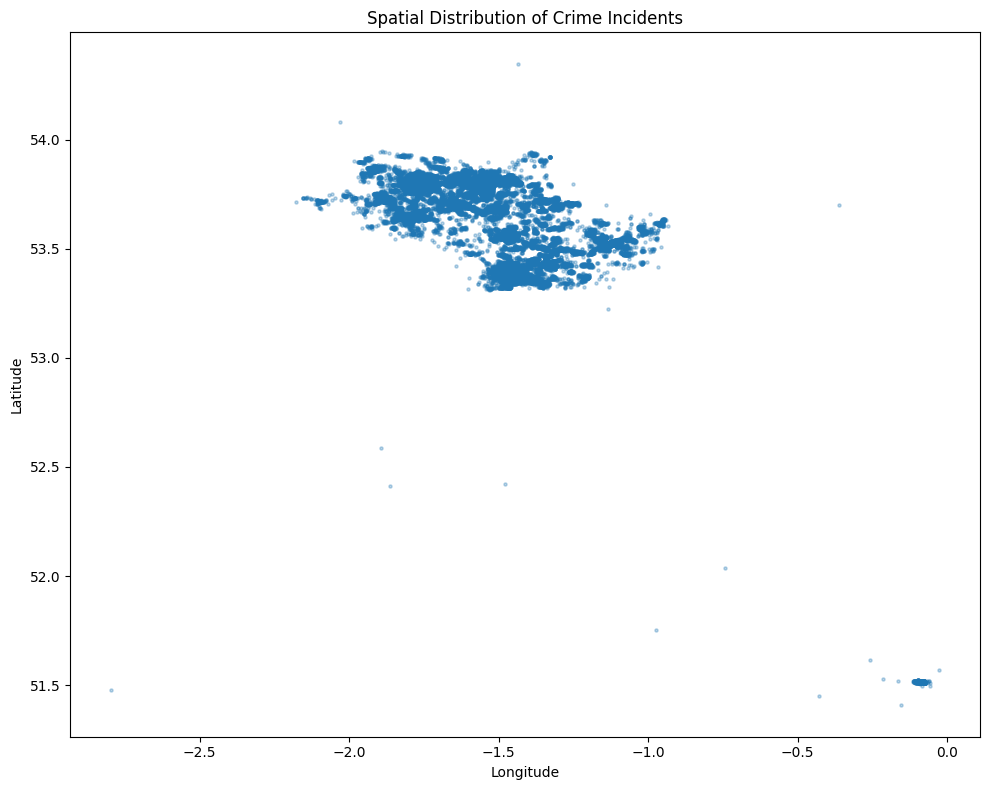

In [101]:
plt.figure(figsize=(10, 8))
plt.scatter(crime_df["longitude"], crime_df["latitude"], alpha=0.3, s=5)
plt.title("Spatial Distribution of Crime Incidents")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

### Summary of Geographical Distribution of Crime Incidents

The scatter plot shows the geographical distribution of crime incidents using longitude and latitude coordinates. Most of the crime incidents are concentrated in a specific area, forming a dense cluster, which likely represents urban regions such as **West Yorkshire** and **South Yorkshire**. There are also a few scattered points outside this main cluster, indicating isolated or less frequent crime occurrences in other areas, such as the **City of London** or rural locations. The dense clustering suggests that crimes are more common in populated areas, while fewer incidents occur in less populated or remote regions.

This analysis was done to understand the spatial distribution of crime and identify geographical patterns. By plotting crime locations on a map-like structure, it becomes easier to see where crimes are concentrated.

This analysis is beneficial because it helps authorities identify crime hotspots and allocate resources more effectively. It supports better urban planning, targeted policing, and improved public safety measures by focusing on areas with higher crime density. It can also help in predicting future crime trends based on location patterns.

# Research Question 9

## Are there spatial hotspots where crime is concentrated?

This question identifies areas where many crime incidents are concentrated close together.

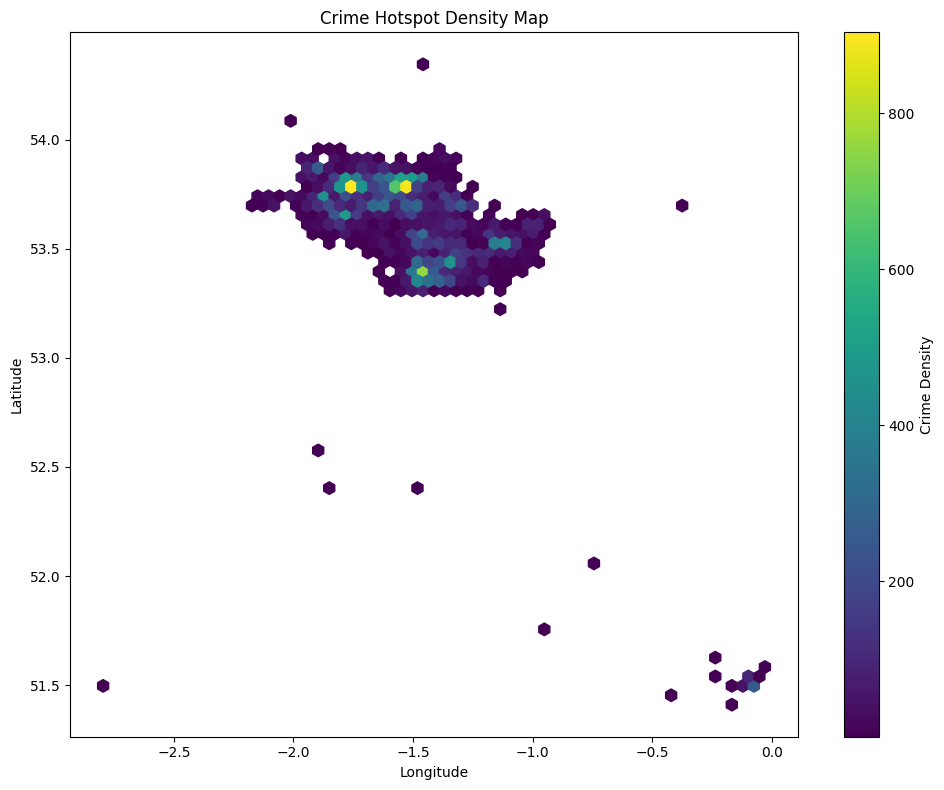

In [102]:
plt.figure(figsize=(10, 8))
hb = plt.hexbin(crime_df["longitude"], crime_df["latitude"], gridsize=60, mincnt=1)
plt.title("Crime Hotspot Density Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
cb = plt.colorbar(hb)
cb.set_label("Crime Density")
plt.tight_layout()
plt.show()

### Summary of Spatial Crime Hotspots

The hot spot density map shows the density of crime incidents across different geographical locations, helping to identify crime hotspots. The areas with brighter colors (yellow and green) represent regions with a high concentration of crimes, while darker areas indicate lower crime density. The map reveals clear hotspots where crimes are clustered closely together, mainly in urban areas such as **West Yorkshire** and **South Yorkshire**. In contrast, areas like the **City of London** and other regions show much lower density with only a few scattered incidents.

This analysis was done to detect spatial hotspots where crimes are concentrated rather than just looking at individual locations. It provides a clearer understanding of how crime clusters geographically.

This analysis is beneficial because it allows law enforcement agencies to focus on high-density crime areas for better surveillance and intervention. Identifying hotspots helps in deploying police resources efficiently, improving public safety, and developing targeted crime prevention strategies. It also supports data-driven decision-making for urban planning and security improvements.

# Research Question 10

## Is there a relationship between the number of crimes at a location and the variety of crime types recorded there?



In [103]:
location_stats = crime_df.groupby(["location","crime_type"]).size().reset_index(name="crime_count")

In [104]:
location_stats["crime_type_code"] = location_stats["crime_type"].astype("category").cat.codes

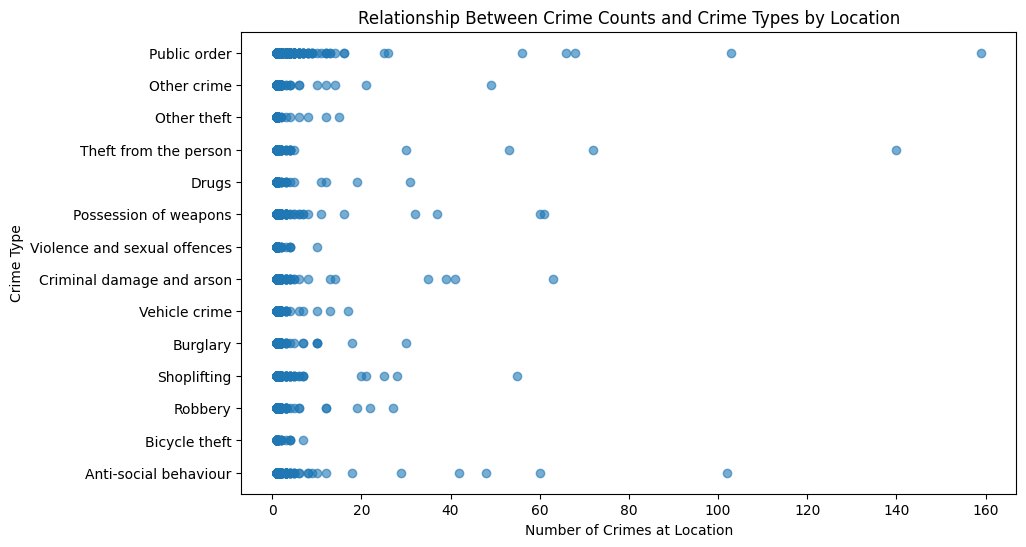

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    location_stats["crime_count"],
    location_stats["crime_type_code"],
    alpha=0.6
)

plt.yticks(
    location_stats["crime_type_code"].unique(),
    location_stats["crime_type"].astype("category").cat.categories
)

plt.xlabel("Number of Crimes at Location")
plt.ylabel("Crime Type")

plt.title("Relationship Between Crime Counts and Crime Types by Location")

plt.show()

### Summary of Relationship Between Crime Counts and Crime Types by Location

This analysis examines the relationship between the number of crimes at a location and different crime types. Although specific location names are not directly visible in the plot, the visualization still reveals important overall patterns. Most observations are concentrated at lower crime counts, indicating that many locations experience relatively low levels of crime. However, a few points extend to higher values, suggesting that some locations have significantly higher numbers of crimes for certain crime types.

This analysis is beneficial because it helps identify general patterns in crime distribution across all locations, rather than focusing on individual places. It highlights variations in crime intensity and shows that crime is not evenly distributed. The presence of higher-value points also helps in identifying potential high-crime cases within the dataset.

This approach was used because it provides a clear way to explore the relationship between numerical values (crime counts at locations) and categorical variables (crime types). Even without explicitly labeling locations, it allows for pattern recognition, detection of outliers, and better understanding of how crime behaves across different categories. This type of analysis is widely applicable to other datasets where relationships between counts and categories need to be explored. This approach can also be applied to other datasets that involve numerical counts and categorical variables. For example, in business, it can be used to analyze the number of sales across different product categories; in healthcare, it can be used to study the number of patients across different diseases; and in transportation, it can be used to examine incidents across different categories. In all these cases, the method helps identify patterns, variations, and extreme values, making it a flexible and useful analytical technique across multiple domains.

# Research Question 11

## What are the most common investigation outcomes?

This question uses the outcome dataset to show what happened after crimes were investigated.

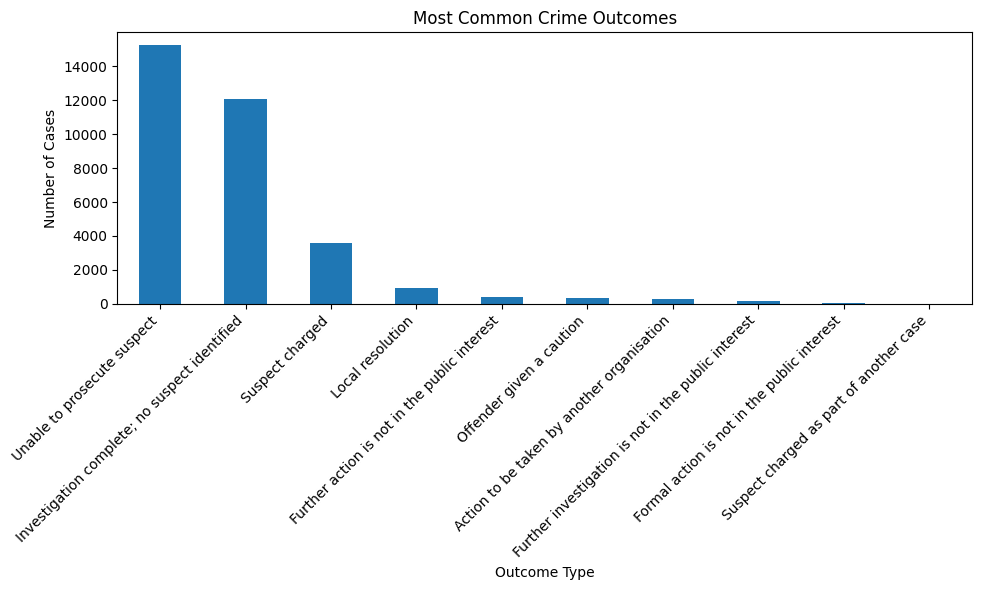

In [106]:
outcome_counts = outcome_df["outcome_type"].value_counts()

plt.figure(figsize=(10, 6))
outcome_counts.head(10).plot(kind="bar")
plt.title("Most Common Crime Outcomes")
plt.xlabel("Outcome Type")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Summary of Most Common Investigation Outcomes

The bar chart shows the most common outcomes of crime investigations. The most frequent outcome is **"Unable to prosecute suspect"**, which has the highest number of cases. This is followed by **"Investigation complete: no suspect identified"**, indicating that many cases are closed without identifying a suspect. **"Suspect charged"** appears as the next most common outcome, showing that some cases do lead to formal charges. Other outcomes such as **local resolution**, **offender given a caution**, and **further action not in the public interest** occur less frequently. The least common outcomes include actions taken by other organisations and cases charged as part of another case.

This analysis was done to understand what happens after crimes are investigated and to evaluate the effectiveness of the justice process. It highlights how many cases lead to prosecution versus those that remain unresolved.

This analysis is beneficial because it helps authorities assess the efficiency of crime investigations and identify gaps in the justice system. For example, a high number of unresolved cases may indicate a need for better investigative resources or techniques. It also supports policymakers in improving legal processes and enhancing overall public safety.

# Research Question 12

## How do investigation outcomes differ across regions?

This question compares investigation outcomes between City of London, South Yorkshire, and West Yorkshire.

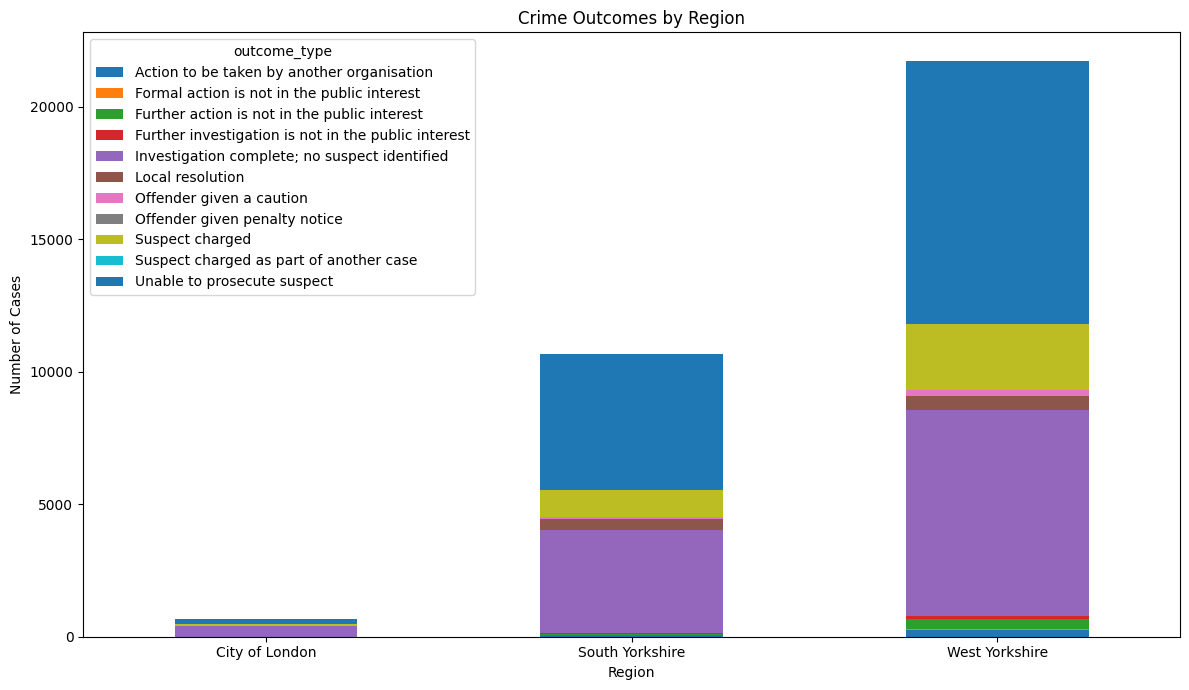

In [107]:
outcome_region_table = pd.crosstab(outcome_df["region"], outcome_df["outcome_type"])

outcome_region_table.plot(kind="bar", stacked=True, figsize=(12, 7))
plt.title("Crime Outcomes by Region")
plt.xlabel("Region")
plt.ylabel("Number of Cases")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Summary of Investigation Outcomes Across Regions

The stacked bar chart compares investigation outcomes across different regions. **West Yorkshire** has the highest number of cases across almost all outcome categories, followed by **South Yorkshire**, while the **City of London** has the lowest number of cases. In all regions, the most common outcomes include **"Unable to prosecute suspect"** and **"Investigation complete: no suspect identified"**, showing that many cases do not lead to a clear resolution. Outcomes such as **suspect charged**, **local resolution**, and **offender given a caution** appear less frequently but are still present across regions.

This analysis was done to compare how investigation outcomes vary between regions and to understand differences in how crimes are handled after investigation.

This analysis is beneficial because it helps evaluate the effectiveness of law enforcement across regions. It allows policymakers to identify regions with higher unresolved cases and improve investigative processes. It also supports better allocation of resources and development of strategies to increase successful case resolutions and improve public safety.

# Research Question 13

## How does mapping the data help us understand crime patterns better?

This question uses GIS mapping to show how geographic visualization makes crime patterns easier to understand.

In [108]:
gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df["longitude"], crime_df["latitude"]),
    crs="EPSG:4326"
)

gdf.head()

,month,longitude,latitude,location,crime_type,region,geometry
0,2025-12,-0.258524,51.615801,On or near Grenville Place,Violence and sexual offences,City of London,POINT (-0.25852 51.6158)
1,2025-12,-1.863241,52.413807,On or near Daleview Road,Other crime,City of London,POINT (-1.86324 52.41381)
2,2025-12,-0.110350,51.518090,On or near Holborn,Bicycle theft,City of London,POINT (-0.11035 51.51809)
3,2025-12,-0.111596,51.518281,On or near Chancery Lane,Shoplifting,City of London,POINT (-0.1116 51.51828)
4,2025-12,-0.111596,51.518281,On or near Chancery Lane,Violence and sexual offences,City of London,POINT (-0.1116 51.51828)


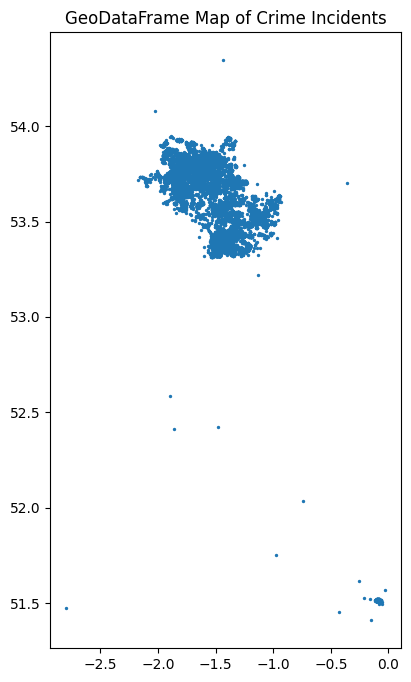

In [109]:
gdf.plot(figsize=(10, 8), markersize=2)
plt.title("GeoDataFrame Map of Crime Incidents")
plt.show()

### Summary of How Mapping Helps Understand Crime Patterns

The map created using geographic data (latitude and longitude) shows the spatial distribution of crime incidents in a more visual way. The plotted points clearly highlight clusters of crime in certain areas, especially in densely populated regions like **West Yorkshire** and **South Yorkshire**, while fewer points appear in areas such as the **City of London**. This visual representation makes it easier to identify where crimes are concentrated and how they are spread across different locations.

This analysis was done to use GIS mapping techniques to better understand crime patterns through geographical visualization. 

This analysis is beneficial because it helps authorities and decision-makers quickly identify crime hotspots and patterns across regions along with other analysis I have done. It supports more effective policing, better urban planning, and targeted safety measures. Additionally, mapping can help predict future crime trends and improve overall crime prevention strategies by focusing on high-risk areas.

In [110]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df["longitude"], crime_df["latitude"]),
    crs="EPSG:4326"
)

gdf.head()

,month,longitude,latitude,location,crime_type,region,geometry
0,2025-12,-0.258524,51.615801,On or near Grenville Place,Violence and sexual offences,City of London,POINT (-0.25852 51.6158)
1,2025-12,-1.863241,52.413807,On or near Daleview Road,Other crime,City of London,POINT (-1.86324 52.41381)
2,2025-12,-0.110350,51.518090,On or near Holborn,Bicycle theft,City of London,POINT (-0.11035 51.51809)
3,2025-12,-0.111596,51.518281,On or near Chancery Lane,Shoplifting,City of London,POINT (-0.1116 51.51828)
4,2025-12,-0.111596,51.518281,On or near Chancery Lane,Violence and sexual offences,City of London,POINT (-0.1116 51.51828)


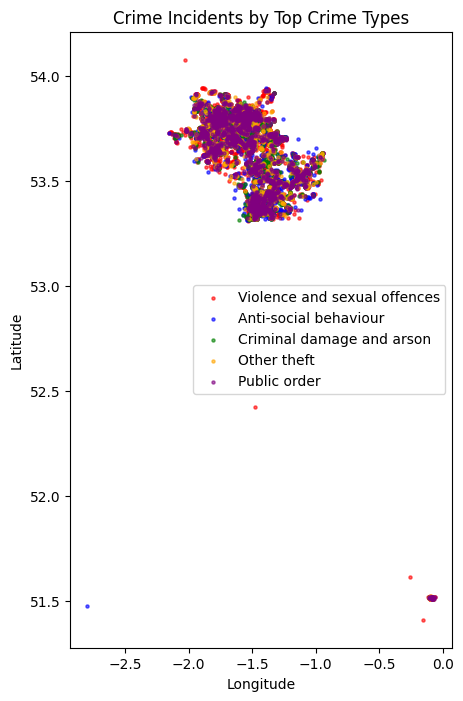

In [111]:
top_types = gdf["crime_type"].value_counts().nlargest(5).index

fig, ax = plt.subplots(figsize=(10, 8))

colors = ["red", "blue", "green", "orange", "purple"]

for i, crime_type in enumerate(top_types):
    data = gdf[gdf["crime_type"] == crime_type]
    
    data.plot(
        ax=ax,
        markersize=5,
        alpha=0.6,
        color=colors[i],
        label=crime_type
    )

ax.set_title("Crime Incidents by Top Crime Types")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.legend()
plt.show()

### Explanation of Crime Incidents by Top Crime Types (Geographica View)

The map visualizes the spatial distribution of crime incidents based on geographic coordinates (longitude and latitude), focusing on the top five most frequent crime types. Each point represents an individual crime event, and different colors are used to distinguish between crime categories.

From the visualization, it is clear that crime incidents are highly concentrated within specific geographic areas, forming visible clusters. These clusters indicate locations where crime activity is more frequent, suggesting the presence of crime hotspots. The overlap of different colored points within the same areas shows that multiple crime types tend to occur in the same locations rather than being isolated to separate regions.

Additionally, there are a few scattered points outside the main clusters, representing less frequent or isolated incidents. These may indicate areas with lower crime activity or occasional occurrences.

By focusing on the top crime types, the map becomes clearer and more interpretable compared to plotting all categories at once. This allows for better comparison between major crime categories and helps in understanding how different types of crime are distributed spatially.

Overall, the map highlights that crime is not evenly distributed and tends to cluster in specific areas, providing useful insights into spatial crime patterns.

In [112]:
import sys
print(sys.executable)

c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.13-64\python.exe


In [113]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=4>
  res = process_handler(cmd, _system_body)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)


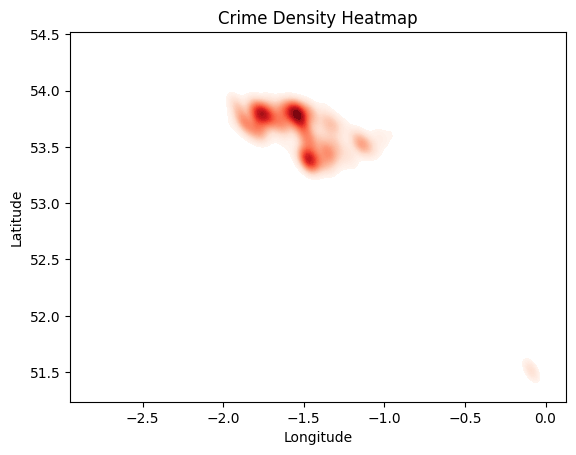

In [114]:
import seaborn as sns

sns.kdeplot(
    x=gdf["longitude"],
    y=gdf["latitude"],
    fill=True,
    cmap="Reds",
    levels=50
)

plt.title("Crime Density Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### Explanation of Crime Density Heatmap

The heatmap visualizes the overall spatial density of crime incidents using geographic coordinates (longitude and latitude). Instead of displaying individual crime points, this visualization aggregates the data to highlight areas where crimes are more concentrated. Darker red regions represent higher densities of crime, while lighter areas indicate lower levels of activity.

From the heatmap, it is evident that crime incidents are not evenly distributed across the region. There are clear hotspots where crime is highly concentrated, particularly in central areas of the map which are West and South Yorkshire regions. These hotspots indicate locations with a higher frequency of crime occurrences. In contrast, areas with little or no shading represent regions like City of London with lower crime activity.

The smoothing effect of the heatmap makes it easier to identify general spatial patterns and areas of high intensity. It also highlights a few smaller or isolated regions with lower density, suggesting occasional crime occurrences outside the main hotspots.

Overall, the heatmap provides a clear and effective way to understand how crime is distributed geographically and helps in identifying areas with higher concentrations of criminal activity.

# ArcGIS online

In [115]:
from arcgis.gis import GIS
from arcgis.features import GeoAccessor



In [116]:
import arcgis

In [117]:
sdf = pd.DataFrame.spatial.from_geodataframe(gdf)
sdf.head()

,month,longitude,latitude,location,crime_type,region,SHAPE
0,2025-12,-0.258524,51.615801,On or near Grenville Place,Violence and sexual offences,City of London,"{""x"": -0.258524, ""y"": 51.615801, ""spatialRefer..."
1,2025-12,-1.863241,52.413807,On or near Daleview Road,Other crime,City of London,"{""x"": -1.863241, ""y"": 52.413807, ""spatialRefer..."
2,2025-12,-0.110350,51.518090,On or near Holborn,Bicycle theft,City of London,"{""x"": -0.11035, ""y"": 51.51809, ""spatialReferen..."
3,2025-12,-0.111596,51.518281,On or near Chancery Lane,Shoplifting,City of London,"{""x"": -0.111596, ""y"": 51.518281, ""spatialRefer..."
4,2025-12,-0.111596,51.518281,On or near Chancery Lane,Violence and sexual offences,City of London,"{""x"": -0.111596, ""y"": 51.518281, ""spatialRefer..."


In [118]:
city = pd.read_csv("2025-12/2025-12-city-of-london-street.csv")
south = pd.read_csv("2025-12/2025-12-south-yorkshire-street.csv")
west = pd.read_csv("2025-12/2025-12-west-yorkshire-street.csv")

In [119]:
city["region"] = "City of London"
south["region"] = "South Yorkshire"
west["region"] = "West Yorkshire"

In [120]:
crime_df = pd.concat([city, south, west], ignore_index=True)
crime_df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context,region
0,4ba571ce58151d00efdc2a532175c128c43fc40de2e8fb...,2025-12,City of London Police,City of London Police,-0.258524,51.615801,On or near Grenville Place,E01000234,Barnet 021D,Violence and sexual offences,Under investigation,NaN,City of London
1,bfc58b45c83aeb05d5356a9f7d262b30af105e93a6430f...,2025-12,City of London Police,City of London Police,-1.863241,52.413807,On or near Daleview Road,E01008940,Birmingham 115B,Other crime,Under investigation,NaN,City of London
2,5d255922432f2b28d6c5cd4d2588b9b31c99b61af7c519...,2025-12,City of London Police,City of London Police,-0.110350,51.518090,On or near Holborn,E01000917,Camden 027C,Bicycle theft,Investigation complete; no suspect identified,NaN,City of London
3,5cce3898a573bdd78c4f3e8db6bacab541e3f9bf6824db...,2025-12,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Shoplifting,Under investigation,NaN,City of London
4,7a0f6468eff5556be2c41dbc76e79439a5d0bdcb7cab6d...,2025-12,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Violence and sexual offences,Under investigation,NaN,City of London


In [121]:
crime_df = crime_df[[
    "Month",
    "Longitude",
    "Latitude",
    "Location",
    "Crime type",
    "region"
]]

crime_df.columns = [
    "month",
    "longitude",
    "latitude",
    "location",
    "crime_type",
    "region"
]

In [122]:
crime_df = crime_df.dropna(subset=["longitude", "latitude"])
crime_df = crime_df.drop_duplicates()
crime_df.head()

,month,longitude,latitude,location,crime_type,region
0,2025-12,-0.258524,51.615801,On or near Grenville Place,Violence and sexual offences,City of London
1,2025-12,-1.863241,52.413807,On or near Daleview Road,Other crime,City of London
2,2025-12,-0.110350,51.518090,On or near Holborn,Bicycle theft,City of London
3,2025-12,-0.111596,51.518281,On or near Chancery Lane,Shoplifting,City of London
4,2025-12,-0.111596,51.518281,On or near Chancery Lane,Violence and sexual offences,City of London


In [123]:
gdf = gpd.GeoDataFrame(
    crime_df,
    geometry=gpd.points_from_xy(crime_df["longitude"], crime_df["latitude"]),
    crs="EPSG:4326"
)

gdf.head()

,month,longitude,latitude,location,crime_type,region,geometry
0,2025-12,-0.258524,51.615801,On or near Grenville Place,Violence and sexual offences,City of London,POINT (-0.25852 51.6158)
1,2025-12,-1.863241,52.413807,On or near Daleview Road,Other crime,City of London,POINT (-1.86324 52.41381)
2,2025-12,-0.110350,51.518090,On or near Holborn,Bicycle theft,City of London,POINT (-0.11035 51.51809)
3,2025-12,-0.111596,51.518281,On or near Chancery Lane,Shoplifting,City of London,POINT (-0.1116 51.51828)
4,2025-12,-0.111596,51.518281,On or near Chancery Lane,Violence and sexual offences,City of London,POINT (-0.1116 51.51828)


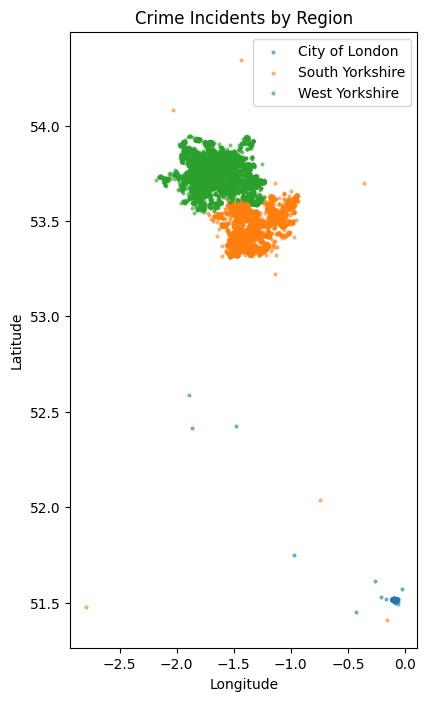

In [124]:
fig, ax = plt.subplots(figsize=(10, 8))

for region, data in gdf.groupby("region"):
    data.plot(ax=ax, markersize=4, alpha=0.5, label=region)

ax.set_title("Crime Incidents by Region")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.show()

### Summary of Crime Incidents by Region (Geographical View)

The map shows the geographical distribution of crime incidents separated by region. Each region is represented with a different color, making it easy to see how crime locations are grouped. **West Yorkshire** and **South Yorkshire** form dense clusters close to each other, indicating a high concentration of crime in these areas. In contrast, the **City of London** appears as a smaller, separate cluster with fewer incidents. There are also a few scattered points outside the main clusters, representing isolated or less frequent crime events.

This analysis was done to compare how crime is geographically distributed across different regions. By visualizing regions separately, it becomes easier to understand their spatial patterns and differences.

This analysis is beneficial because it helps identify regional crime clusters and understand how crime is concentrated geographically. It allows law enforcement to allocate resources more effectively, focus on high-density areas, and develop region-specific strategies for crime prevention. It also improves overall understanding of how crime patterns vary across locations.

### Overall Findings of Interest

The analysis reveals that crime is highly concentrated both geographically and by type. **West Yorkshire** consistently shows the highest number of crime incidents across multiple analyses, making it the most affected region. In contrast, the **City of London** has significantly lower crime levels.

Across all regions, **violence and sexual offences** and **anti-social behaviour** are the most common crime types, indicating that everyday public safety issues are more frequent than serious but less common crimes like robbery or weapon possession.

Geographical analysis shows that crimes are not randomly distributed but are clustered in specific urban areas, creating clear **crime hotspots**. These high-density areas also tend to experience a wider variety of crime types, suggesting that busy or populated locations attract multiple forms of criminal activity.

Additionally, investigation outcome analysis highlights that many cases result in **no suspect identified** or **unable to prosecute**, indicating potential challenges in solving crimes.

Overall, the findings suggest that crime is concentrated in specific regions, locations, and categories, and that targeted, data-driven strategies are essential for effective crime prevention and resource allocation.

In [125]:
crime_df.to_csv("crime_points.csv", index=False)

In [126]:
gis = GIS()
gis.properties

{
  "2DSketchStylesGroupQuery": "title:\"Esri Sketch Styles\" AND owner:esri_en",
  "2DStylesGroupQuery": "title:\"Esri 2D Styles\" AND owner:esri_en",
  "3DBasemapGalleryGroupQuery": "title:\"ArcGIS Online 3D Basemaps\" AND owner:esri_en",
  "analysisLayersGroupQuery": "title:\"Living Atlas Analysis Layers\" AND owner:esri",
  "basemapGalleryGroupQuery": "title:\"United States Basemaps\" AND owner:Esri_cy_US",
  "cdnUrl": "https://cdn.arcgis.com",
  "colorSetsGroupQuery": "title:\"Esri Colors\" AND owner:esri_en",
  "contentCategorySetsGroupQuery": "title:\"ArcGIS Online Content Category Sets\" AND owner:esri_en",
  "customBaseUrl": "maps.arcgis.com",
  "default3DBasemapQuery": "typekeywords:\"sourceId#topographic\" AND type:\"Web Scene\" AND owner:esri_en",
  "defaultBasemap": {
    "baseMapLayers": [
      {
        "url": "https://services.arcgisonline.com/ArcGIS/rest/services/World_Topo_Map/MapServer",
        "layerType": "ArcGISTiledMapServiceLayer",
        "resourceInfo": {
  

In [127]:
gis.properties.portalName

'ArcGIS Online'

In [128]:
import getpass
print("Portal for ArcGIS as a built in user")
pwd = getpass.getpass('PASSWORD: ')
gis_wmu = GIS("https://wmugeography.maps.arcgis.com", "FFarooqiWMU26", pwd)
print("Logged in as: " + gis_wmu.properties.user.username)

Portal for ArcGIS as a built in user


Exception: A general error occurred: Invalid username or password.

In [ ]:
import os
print(os.path.exists("crime_points.csv"))

True


In [ ]:
print(gis_wmu.users.me)

<User username:FFarooqiWMU26>


In [ ]:
csv_item = gis_wmu.content.add(
    item_properties={
        "title": "UK Crime Points December 2025",
        "type": "CSV",
        "tags": "UK crime, student project, GIS, ArcGIS Online"
    },
    data="crime_points.csv"
)

csv_item

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3747: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


Exception: Item 'crime_points.csv' already exists.
(Error Code: 409)

In [ ]:
published_layer = csv_item.publish()
published_layer

Exception: Unable to publish item.
User 'FFarooqiWMU26' does not have publishing privileges.
(Error Code: 400)

## Summary

In this project, I worked with UK crime data for December 2025 from multiple regions, including the City of London, South Yorkshire, and West Yorkshire. The data was collected in CSV format and combined into a single dataset for analysis.

The dataset was cleaned by removing missing values and duplicates. Important columns such as longitude, latitude, location, and crime type were selected and standardized. A new column for region was also created to clearly distinguish between different areas.

After cleaning, the dataset was converted into a GeoDataFrame using longitude and latitude coordinates. This allowed the data to be visualized spatially. Maps were created to show crime incidents by region, helping to understand how crime is distributed geographically.



## Conclusion

The analysis of UK crime data for December 2025 reveals clear spatial patterns across the selected regions. The visualization shows that crime incidents are clustered rather than evenly distributed.

From the map, South Yorkshire and West Yorkshire display a higher concentration of crime points compared to the City of London in this dataset. This suggests that, within the selected data, these regions have more recorded incidents or denser clusters of crime locations.

The results also show that different types of crimes, including violence, theft, and shoplifting, are present across all regions. However, the spatial clustering indicates that certain areas experience more frequent incidents, forming visible hotspots.

This analysis highlights the importance of spatial visualization in understanding crime distribution. By mapping the data, it becomes easier to identify high-density areas and patterns that are not obvious in raw data tables.

Overall, the project demonstrates how geographic data analysis can provide meaningful insights into crime patterns and support better understanding of regional differences.

## Self Reflection

During this project, I learned how to work with real-world datasets and handle challenges such as missing values, inconsistent data, and combining multiple files. I improved my skills in data cleaning, data manipulation, and working with pandas and GeoPandas.

One of the most valuable parts of this project was understanding how geographic data works. Converting a normal dataset into a GeoDataFrame helped me see how spatial data can be visualized and analyzed effectively.


Overall, this project improved my confidence in working with data and GIS tools but still learning. It also showed me how important it is to prepare and clean data properly before visualization. In future projects, I would like to explore more advanced visualizations and deeper analysis of patterns in the data.

## ArcGIS Online Web Map Creation

The cleaned and processed crime dataset was successfully exported as a CSV file.

Due to limitations in account permissions, publishing the dataset as a hosted feature layer directly from the Jupyter Notebook was not possible. As a result, the web map was created manually using the ArcGIS Online Map Viewer.

The uploaded CSV file was added to the Map Viewer, where longitude and latitude fields were used to generate spatial point features. The data was then symbolized by region and visualized using clustering to better represent the density and distribution of crime incidents.

The final web map clearly highlights spatial patterns and crime hotspots across the selected regions.

The link to the web map is:
https://arcg.is/1j8n1a2
